In [8]:
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ast
import pandas as pd
import altair as alt

df = pd.read_csv("Movie_Data_File.csv")

rating_cols = ['½','★','★½','★★','★★½','★★★','★★★½','★★★★','★★★★½','★★★★★']
df["Total_Ratings_Calc"] = df[rating_cols].sum(axis=1)

df["Average_Rating"] = df["Average_rating"]
df["Language"] = df["Original_language"]

df["Reviews_Millions"] = df["Total_Ratings_Calc"] / 1_000_000

# parse list, take first genre, clean leading "[" artifact
def clean_first_genre(val):
    try:
        genres = ast.literal_eval(val)
        if isinstance(genres, list) and len(genres) > 0:
            return genres[0].strip().title()
    except Exception:
        pass
    return str(val).strip().lstrip("[").strip("'\"").strip().title()

df["Top_Genre"] = df["Genres"].apply(clean_first_genre)

unique_movies = df.drop_duplicates(subset="Film_title")

top_movies = unique_movies.sort_values(
    "Total_Ratings_Calc",
    ascending=False
).head(150)

rating_median = top_movies["Average_Rating"].median()
review_median = top_movies["Reviews_Millions"].median()

def assign_quadrant(row):
    if row["Average_Rating"] >= rating_median and row["Reviews_Millions"] >= review_median:
        return "Acclaimed blockbusters"
    elif row["Average_Rating"] < rating_median and row["Reviews_Millions"] >= review_median:
        return "Commercial triumphs"
    elif row["Average_Rating"] >= rating_median and row["Reviews_Millions"] < review_median:
        return "Cult classics"
    else:
        return "Underperformers"

top_movies = top_movies.copy()
top_movies["Quadrant"] = top_movies.apply(assign_quadrant, axis=1)

colors = {
    "Acclaimed blockbusters": "#2a9d8f",
    "Commercial triumphs":    "#e9c46a",
    "Cult classics":          "#185FA5",
    "Underperformers":        "#adb5bd"
}

# brush selection on the scatter
brush = alt.selection_interval(name="brush")

scatter = alt.Chart(top_movies).mark_circle(size=60).encode(
    x=alt.X(
        "Average_Rating:Q",
        title="Average Rating",
        scale=alt.Scale(domain=[2.5, 5]),
        axis=alt.Axis(tickCount=6, format=".1f")
    ),
    y=alt.Y(
        "Reviews_Millions:Q",
        title="Reviews (Millions)",
        axis=alt.Axis(format=".1f", tickCount=6)
    ),
    color=alt.condition(
        brush,
        alt.Color(
            "Quadrant:N",
            scale=alt.Scale(domain=list(colors.keys()), range=list(colors.values()))
        ),
        alt.value("lightgrey")
    ),
    opacity=alt.condition(brush, alt.value(0.85), alt.value(0.25)),
    tooltip=[
        "Film_title:N",
        "Top_Genre:N",
        "Language:N",
        alt.Tooltip("Average_Rating:Q", format=".2f"),
        alt.Tooltip("Reviews_Millions:Q", format=".2f")
    ]
).add_params(brush).properties(
    width=560,
    height=380,
    title="Rating vs. Review Volume — Quadrant Analysis (drag to select)"
).interactive()

vline = alt.Chart(pd.DataFrame({"x": [rating_median]})).mark_rule(strokeDash=[5,5], color="#6b7280").encode(x="x:Q")
hline = alt.Chart(pd.DataFrame({"y": [review_median]})).mark_rule(strokeDash=[5,5], color="#6b7280").encode(y="y:Q")

# genre distribution bar chart — linked to brush selection
genre_bar = alt.Chart(top_movies).mark_bar().encode(
    x=alt.X("count():Q", title="Number of Films"),
    y=alt.Y("Top_Genre:N", sort="-x", title="Genre"),
    color=alt.Color(
        "Quadrant:N",
        scale=alt.Scale(domain=list(colors.keys()), range=list(colors.values())),
        legend=None
    ),
    tooltip=[
        alt.Tooltip("Top_Genre:N", title="Genre"),
        alt.Tooltip("count():Q", title="Count"),
        alt.Tooltip("Quadrant:N", title="Quadrant")
    ]
).transform_filter(
    brush
).properties(
    width=560,
    height=300,
    title="Genre Distribution of Selected Films"
)

scatter_chart = (scatter + vline + hline) & genre_bar
scatter_chart.save("images/scatter_rating_reviews.html")
scatter_chart.display()

alt.VConcatChart(...)

In [ ]:
# remove duplicate films caused by exploding genres
unique_movies = df.drop_duplicates(subset="Film_title")

# filter movies with more than 500,000 reviews
filtered_movies = unique_movies[
    unique_movies["Total_Ratings_Calc"] > 500_000
]

# calculate average rating
avg_rating_500k = filtered_movies["Average_Rating"].mean()

print("Average Rating (Movies > 500k Reviews):",
      round(avg_rating_500k, 3))

print("Number of movies in this group:",
      len(filtered_movies))

Average Rating (Movies > 500k Reviews): 3.77
Number of movies in this group: 522


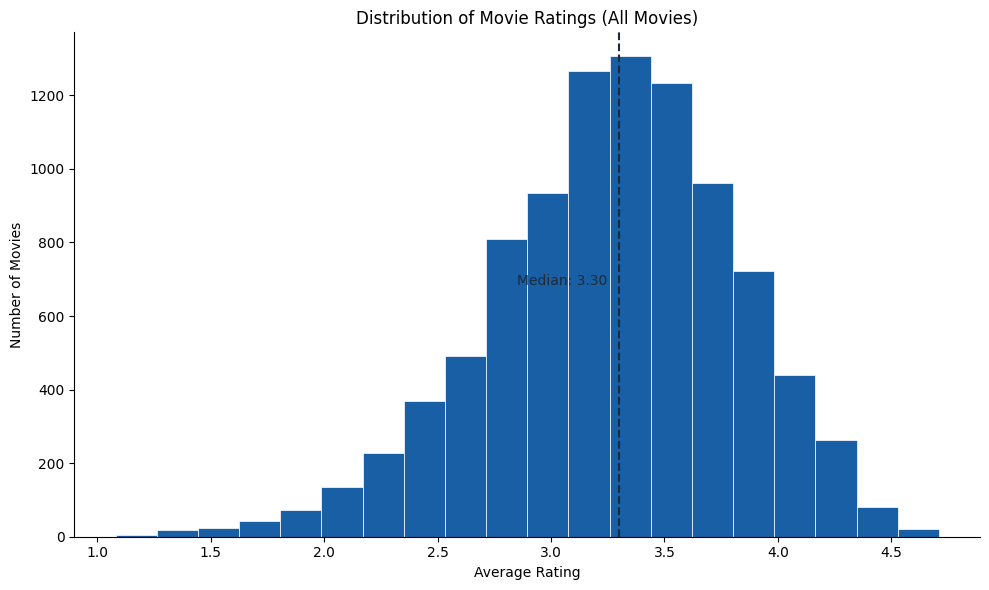

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# use full dataset instead of top_movies
ratings = df["Average_Rating"].dropna()

median_rating = ratings.median()

plt.figure(figsize=(10, 6))

plt.hist(ratings, bins=20, color="#185FA5", edgecolor="white", linewidth=0.5)

plt.axvline(median_rating, linestyle="--", color="#1c2b3a", linewidth=1.5)

plt.text(
    median_rating - 0.05,
    plt.ylim()[1]*0.5,
    f"Median: {median_rating:.2f}",
    ha="right",
    color="#1c2b3a",
    fontsize=10
)

plt.xlabel("Average Rating")
plt.ylabel("Number of Movies")
plt.title("Distribution of Movie Ratings (All Movies)")
plt.gca().spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig("images/rating_distribution.png", bbox_inches="tight", dpi=150)
plt.show()


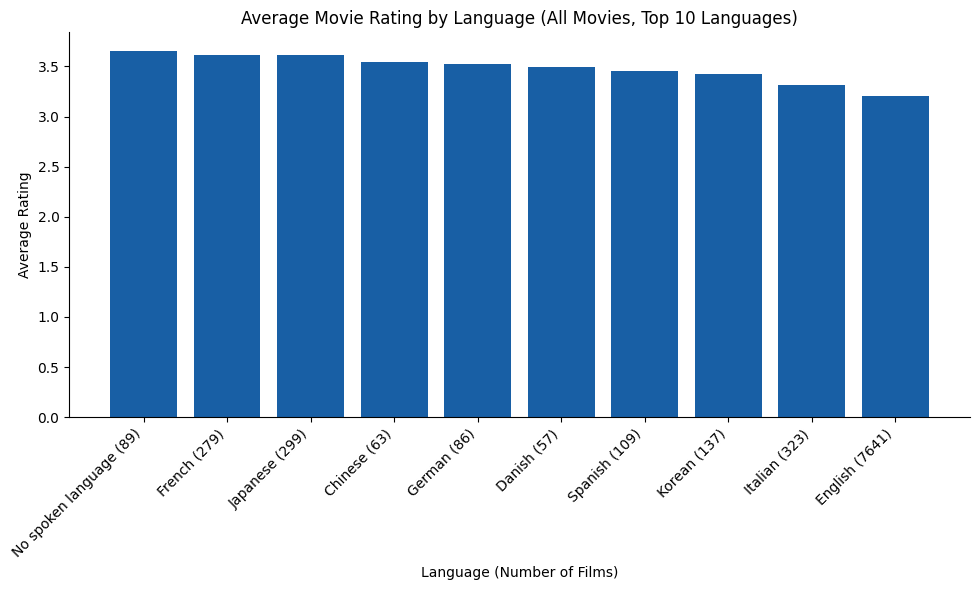

In [13]:
import matplotlib.pyplot as plt

# use full dataset
language_counts = df["Language"].value_counts()

# keep top 10 languages by number of films
top_languages = language_counts.head(10).index

filtered = df[df["Language"].isin(top_languages)]

language_stats = (
    filtered.groupby("Language")
    .agg(
        avg_rating=("Average_Rating", "mean"),
        film_count=("Average_Rating", "count")
    )
    .sort_values("avg_rating", ascending=False)
)

labels = [
    f"{lang} ({count})"
    for lang, count in zip(language_stats.index, language_stats["film_count"])
]

plt.figure(figsize=(10, 6))

plt.bar(labels, language_stats["avg_rating"], color="#185FA5")

plt.xlabel("Language (Number of Films)")
plt.ylabel("Average Rating")
plt.title("Average Movie Rating by Language (All Movies, Top 10 Languages)")
plt.gca().spines[["top", "right"]].set_visible(False)

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/rating_by_language.png", bbox_inches="tight", dpi=150)
plt.show()
